## **<span style="color:red">- Feature Selection</span>**

In this project (real estate price prediction), we have many features, but:

•	Not all features contribute equally to prediction<br>
•	Some features may introduce noise or redundancy<br>
•	Reducing features improves:
        - Model performance
        - Training speed
        - Interpretability

👉 Therefore, we apply multiple feature selection techniques to identify the most important features from different perspectives.


<br>

#### **<span style="color:black">- Dataset</span>**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')
df.shape

(3498, 17)

In [5]:
df.head()

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7586.0,3,2,2,New Property,850.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8597.0,2,2,2,New Property,1226.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sohna road,0.32,5470.0,2,2,1,New Property,1000.0,0,0,0,0,0,semifurnished,High Floor,Low
3,flat,sector 92,1.60,8020.0,3,4,3+,Relatively New,1615.0,0,1,0,0,1,furnished,Mid Floor,High
4,flat,sector 102,0.48,9023.0,2,2,1,Relatively New,581.0,0,0,1,0,0,semifurnished,Mid Floor,High


In [6]:
train_df = df.drop(columns=['price_per_sqft'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,semifurnished,High Floor,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,furnished,Mid Floor,High
4,flat,sector 102,0.48,2,2,1,Relatively New,581.0,0,0,1,0,0,semifurnished,Mid Floor,High


<br>

#### **<span style="color:black">1. Ordinal Encoding</span>**

For different types of models, different encoding techniques are preferred: <br><br>
o	**For Linear Models:** We would typically use **One-Hot Encoding (OHE)** to avoid introducing ordinal relationships.

o	**For Non-Linear Models:** We use **Ordinal Encoding**, as tree-based models can handle categorical ordering effectively without being affected by scale.


In [7]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [8]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,0.0,40.0,3,2,2.0,1.0,850.0,0,0,0,0,0,1.0,1.0,1.0
1,0.0,101.0,2,2,2.0,1.0,1226.0,1,1,0,0,0,1.0,2.0,1.0
2,0.0,111.0,2,2,1.0,1.0,1000.0,0,0,0,0,0,1.0,0.0,1.0
3,0.0,105.0,3,4,4.0,3.0,1615.0,0,1,0,0,1,0.0,2.0,0.0
4,0.0,4.0,2,2,1.0,3.0,581.0,0,0,1,0,0,1.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,1.0,67.0,4,4,2.0,0.0,480.0,0,0,0,0,0,1.0,1.0,1.0
3494,0.0,96.0,2,2,1.0,3.0,532.0,0,0,0,0,0,1.0,2.0,2.0
3495,1.0,11.0,5,5,4.0,3.0,6228.0,1,1,1,1,0,1.0,1.0,0.0
3496,1.0,50.0,5,6,3.0,0.0,5490.0,1,1,1,1,0,1.0,2.0,2.0


In [9]:
y_label

0        0.82
1        0.95
2        0.32
3        1.60
4        0.48
        ...  
3493     0.75
3494     0.37
3495     6.00
3496    15.50
3497     1.78
Name: price, Length: 3498, dtype: float64

<br>

#### **<span style="color:black">2. Feature Selection</span>**

<br>

##### **<span style="color:green">Technique 1 - Correlation Analysis</span>**

Correlation Analysis: Measures linear relationship between features and target

Correlation can be positive or negative
- Both strong +ve and -ve are important

<Axes: >

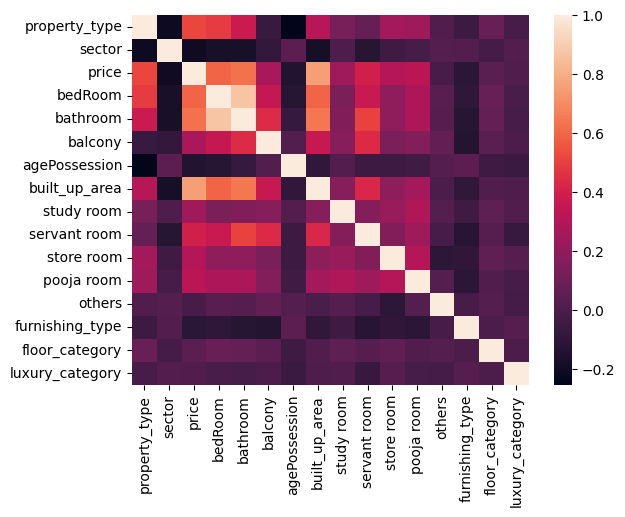

In [10]:
sns.heatmap(data_label_encoded.corr())

In [21]:
# Compute correlation matrix of all features w.r.t 'price'
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'}).sort_values(by='corr_coeff', ascending=False)
fi_df1      # feature importance DataFrame 1

,feature,corr_coeff
1,price,1.000000
6,built_up_area,0.751862
3,bathroom,0.626823
2,bedRoom,0.590413
8,servant room,0.394417
10,pooja room,0.321846
9,store room,0.306689
4,balcony,0.268066
7,study room,0.242171
13,floor_category,0.041197


🔸 Very Weak (almost no relationship)
- luxury_category → 0.007
- others → -0.016
- floor_category → 0.041

Overall Features with low correlation (< 0.3) are considered weak, but they should not be dropped without checking other methods.

<br>

##### **<span style="color:Green">Technique 2 - Random Forest Feature Importance</span>**

Random Forest Feature Importance: Captures non-linear relationships using ensemble trees

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.656626
1,sector,0.105146
0,property_type,0.098431
2,bedRoom,0.024756
3,bathroom,0.023759
8,servant room,0.017967
5,agePossession,0.014978
4,balcony,0.011392
12,furnishing_type,0.009246
9,store room,0.008617


<br>

##### **<span style="color:Green">Technique 3 - Gradient Boosting Feature importances</span>**

Gradient Boosting Feature Importance: Provides importance based on boosting models

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.690770
0,property_type,0.098247
1,sector,0.097126
2,bedRoom,0.034181
3,bathroom,0.030748
8,servant room,0.023270
9,store room,0.013069
5,agePossession,0.004198
7,study room,0.003954
4,balcony,0.001628


<br>

##### **<span style="color:Green">Technique 4 - Permutation Importance</span>**

Permutation Importance: Measures performance drop when a feature is shuffled

In [20]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.682904
0,property_type,0.208912
1,sector,0.142858
8,servant room,0.015615
3,bathroom,0.008602
2,bedRoom,0.006449
4,balcony,0.004923
7,study room,0.004203
9,store room,0.003554
13,floor_category,0.002683


<br>

##### **<span style="color:Green">Technique 5 - LASSO</span>**

o	Shrinks less important feature coefficients to zero  
o	- ⚠     Less reliable here due to use of Ordinal Encoding


In [22]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
6,built_up_area,1.483714
0,property_type,0.741004
3,bathroom,0.434498
9,store room,0.209621
7,study room,0.170947
8,servant room,0.144311
10,pooja room,0.097034
14,luxury_category,0.035938
13,floor_category,-0.000000
5,agePossession,-0.010763


<br>

##### **<span style="color:Green">Technique 6 - RFE</span>**

Recursive Feature Elimination (RFE): Iteratively removes least important features

In [23]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.651834
1,sector,0.105872
0,property_type,0.101828
3,bathroom,0.023775
2,bedRoom,0.022235
8,servant room,0.020569
5,agePossession,0.013017
4,balcony,0.011745
12,furnishing_type,0.009677
7,study room,0.009061


<br>

##### **<span style="color:Green">Technique 7 - Linear Regression Weights</span>**

o	Uses coefficients as importance  
o	⚠    Less reliable due to encoding and non-linearity


In [24]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
6,built_up_area,1.490582
0,property_type,0.754683
3,bathroom,0.516590
9,store room,0.213287
7,study room,0.179023
8,servant room,0.145205
10,pooja room,0.103168
14,luxury_category,0.046633
13,floor_category,-0.008416
5,agePossession,-0.019923


<br>

##### **<span style="color:Green">Technique 8 - SHAP</span>**

SHAP (SHapley Additive exPlanations): Provides consistent and interpretable feature contributions

In [ ]:
!pip install shap

In [26]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[-0.17897683,  0.11308754, -0.02338876, ..., -0.01038972,
        -0.00948008, -0.00336495],
       [-0.19509301, -0.41420641, -0.0499806 , ..., -0.00891963,
        -0.00651186, -0.00540604],
       [-0.16970756, -0.43267858, -0.04432516, ..., -0.01007127,
        -0.01298529, -0.01188564],
       ...,
       [ 0.90765212, -1.33083261,  0.19902583, ..., -0.00919526,
        -0.00488935, -0.05102396],
       [ 1.53377159,  0.97165167,  0.42260956, ...,  0.09670913,
         0.02155265,  0.02934856],
       [-0.26302433,  0.02378104, -0.02716783, ..., -0.00166202,
         0.04171011, -0.01150258]])

In [27]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.271969
0,property_type,0.453321
1,sector,0.391716
3,bathroom,0.106154
8,servant room,0.090602
2,bedRoom,0.053078
4,balcony,0.038956
5,agePossession,0.026630
13,floor_category,0.025160
12,furnishing_type,0.023867


<br>

#### **<span style="color:black">3. Aggregation Process</span>**

After applying all methods:
1.	Convert results into separate DataFrames  & **Merge all DataFrames** into a single structure  
2.	**Normalize feature importance values** (to make them comparable)  
3.	Compute the **mean (average importance)** across all methods  

👉 This gives a **final consolidated importance score**


<br>

##### **<span style="color:green">1. Convert results into separate DataFrames  & **Merge all DataFrames** into a single structure  </span>**

In [28]:
final_fi_df = (
    fi_df1
    .merge(fi_df2, on='feature')
    .merge(fi_df3, on='feature')
    .merge(fi_df4, on='feature')
    .merge(fi_df5, on='feature')
    .merge(fi_df6, on='feature')
    .merge(fi_df7, on='feature')
    .merge(fi_df8, on='feature')
    .set_index('feature')
)

final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
built_up_area,0.751862,0.656626,0.690770,0.682904,1.483714,0.651834,1.490582,1.271969
bathroom,0.626823,0.023759,0.030748,0.008602,0.434498,0.023775,0.516590,0.106154
bedRoom,0.590413,0.024756,0.034181,0.006449,-0.106444,0.022235,-0.197950,0.053078
servant room,0.394417,0.017967,0.023270,0.015615,0.144311,0.020569,0.145205,0.090602
pooja room,0.321846,0.005661,0.000261,0.002376,0.097034,0.006456,0.103168,0.011851
store room,0.306689,0.008617,0.013069,0.003554,0.209621,0.007626,0.213287,0.018654
balcony,0.268066,0.011392,0.001628,0.004923,-0.023936,0.011745,-0.043006,0.038956
study room,0.242171,0.007802,0.003954,0.004203,0.170947,0.009061,0.179023,0.019412
floor_category,0.041197,0.005608,0.000579,0.002683,-0.000000,0.006135,-0.008416,0.025160


<br>

##### **<span style="color:green">2. Normalize feature importance values (to make them comparable)  </span>**

In [29]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
built_up_area,0.244089,0.728314,0.766030,0.783689,0.636212,0.725735,0.648549,0.605417
bathroom,0.203495,0.026353,0.034098,0.009871,0.186311,0.026471,0.224767,0.050526
bedRoom,0.191675,0.027459,0.037905,0.007400,-0.045643,0.024756,-0.086128,0.025264
servant room,0.128046,0.019929,0.025805,0.017920,0.061880,0.022901,0.063178,0.043124
pooja room,0.104486,0.006279,0.000289,0.002727,0.041608,0.007188,0.044888,0.005641
store room,0.099565,0.009558,0.014493,0.004079,0.089885,0.008491,0.092801,0.008879
balcony,0.087026,0.012635,0.001806,0.005650,-0.010264,0.013076,-0.018712,0.018542
study room,0.078620,0.008653,0.004385,0.004823,0.073302,0.010088,0.077892,0.009240
floor_category,0.013374,0.006220,0.000642,0.003078,-0.000000,0.006830,-0.003662,0.011975


<br>

##### **<span style="color:green">3. Compute the **mean (average importance)** across all methods   </span>**

In [30]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.721837
sector             0.138519
bathroom           0.029464
servant room       0.025936
bedRoom            0.024557
balcony            0.010342
agePossession      0.009177
store room         0.009100
study room         0.007438
furnishing_type    0.006740
floor_category     0.005749
pooja room         0.004425
luxury_category    0.004260
others             0.002457
dtype: float64

<br>

#### **<span style="color:black">4. Droping the Features</span>**

In Machine Learning, we cannot drop features arbitrarily. We need to prove that they are not contributing to the model’s performance.

So, my plan is to train a Random Forest Regressor both with and without the least important features. If removing those features does not improve the model’s performance, we will drop them.

In [32]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')
scores.mean()

np.float64(0.8193132850095542)

In [ ]:
# Without the least important features --> 'others','luxury_category','pooja room'
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['others','luxury_category','pooja room']), y_label, cv=5, scoring='r2')
scores.mean()

np.float64(0.8245302300298294)

Dropping:
- others
- luxury_category
- pooja room

<br>

**Result:** R² increased (0.819 → 0.8245)

✔ Means:
- These features were adding noise
- Model performs better without them

In [8]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,semifurnished,High Floor,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,furnished,Mid Floor,High
4,flat,sector 102,0.48,2,2,1,Relatively New,581.0,0,0,1,0,0,semifurnished,Mid Floor,High


In [9]:
# Its very sad that I have to drop  'luxury_category' feature that I created with full of love
train_df = train_df.drop(columns=['pooja room', 'luxury_category', 'others'])
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,semifurnished,Low Floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,semifurnished,Mid Floor
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,semifurnished,High Floor
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,furnished,Mid Floor
4,flat,sector 102,0.48,2,2,1,Relatively New,581.0,0,0,1,semifurnished,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,house,sector 6,0.75,4,4,2,Moderately Old,480.0,0,0,0,semifurnished,Low Floor
3494,flat,sector 84,0.37,2,2,1,Relatively New,532.0,0,0,0,semifurnished,Mid Floor
3495,house,sector 109,6.00,5,5,3+,Relatively New,6228.0,1,1,1,semifurnished,Low Floor
3496,house,sector 43,15.50,5,6,3,Moderately Old,5490.0,1,1,1,semifurnished,Mid Floor


In [10]:
train_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)